<a href="https://colab.research.google.com/github/Deepak969686/CEI-Internship-assignments/blob/main/Week_5_Assignment_Deepak_Kumar_Saini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Load Dataset

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# Dataset Information

In [ ]:
lines=[line for line in corpus.split("\n") if line.strip()]

print("Number of Sentences:",len(lines))

total_words=len(corpus.split())

print("Total Words:",total_words)

Number of Sentences: 6
Total Words: 41


# Tokanization

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary Size :", total_words)
print(tokenizer.word_index)

Vocabulary Size : 37
{'deep': 1, 'learning': 2, 'is': 3, 'lstm': 4, 'models': 5, 'transforming': 6, 'artificial': 7, 'intelligence': 8, 'recurrent': 9, 'neural': 10, 'networks': 11, 'are': 12, 'useful': 13, 'for': 14, 'sequential': 15, 'data': 16, 'helps': 17, 'remember': 18, 'long': 19, 'term': 20, 'dependencies': 21, 'gru': 22, 'faster': 23, 'and': 24, 'simpler': 25, 'than': 26, 'text': 27, 'generation': 28, 'predict': 29, 'the': 30, 'next': 31, 'word': 32, 'can': 33, 'generate': 34, 'meaningful': 35, 'sentences': 36}


# Create input sequence

In [ ]:
input_sequences = []

for line in lines:

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Maximum Length :", max_len)

print("Input Shape :", X.shape)

print("Output Shape :", y.shape)

Maximum Length : 8
Input Shape : (35, 7)
Output Shape : (35,)


# Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(28, 7)
(7, 7)


# EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Model 1- Vanilla RNN Model

In [ ]:
rnn_model=Sequential([
    Embedding(total_words,64,input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words,activation="softmax")
])

rnn_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_history=rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 3.6068 - val_accuracy: 0.0000e+00 - val_loss: 3.6399
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.1429 - loss: 3.5493 - val_accuracy: 0.0000e+00 - val_loss: 3.6390
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2500 - loss: 3.4933 - val_accuracy: 0.0000e+00 - val_loss: 3.6406
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.3571 - loss: 3.4366 - val_accuracy: 0.0000e+00 - val_loss: 3.6464
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.3571 - loss: 3.3776 - val_accuracy: 0.0000e+00 - val_loss: 3.6590
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.3571 - loss: 3.3152 - val_accuracy: 0.0000e+00 - val_loss: 3.6820
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3571 - loss: 3.2492 - val_accuracy: 0.0000e+00 - val_loss: 3.7202
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.3214 - loss: 3.18

# Model 2-LSTM Model

In [ ]:
lstm_model=Sequential([
    Embedding(total_words,64,input_length=max_len-1),
    LSTM(128),
    Dense(total_words,activation="softmax")
])

lstm_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history=lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 3.6125 - val_accuracy: 0.0000e+00 - val_loss: 3.6160
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.0714 - loss: 3.6061 - val_accuracy: 0.0000e+00 - val_loss: 3.6186
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1429 - loss: 3.5997 - val_accuracy: 0.0000e+00 - val_loss: 3.6214
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.1786 - loss: 3.5932 - val_accuracy: 0.0000e+00 - val_loss: 3.6245
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1786 - loss: 3.5863 - val_accuracy: 0.0000e+00 - val_loss: 3.6280
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.1786 - loss: 3.5788 - val_accuracy: 0.0000e+00 - val_loss: 3.6320
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.1429 - loss: 3.5707 - val_accuracy: 0.0000e+00 - val_loss: 3.6366
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.1429 - loss: 3.56

# Model 3-GRU Model

In [ ]:
gru_model=Sequential([
    Embedding(total_words,64,input_length=max_len-1),
    GRU(128),
    Dense(total_words,activation="softmax")
])

gru_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_history=gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 3.6124 - val_accuracy: 0.0000e+00 - val_loss: 3.6106
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.0714 - loss: 3.6023 - val_accuracy: 0.0000e+00 - val_loss: 3.6119
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1786 - loss: 3.5921 - val_accuracy: 0.0000e+00 - val_loss: 3.6135
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.2500 - loss: 3.5816 - val_accuracy: 0.0000e+00 - val_loss: 3.6153
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.2500 - loss: 3.5707 - val_accuracy: 0.0000e+00 - val_loss: 3.6176
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.2500 - loss: 3.5593 - val_accuracy: 0.0000e+00 - val_loss: 3.6203
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1786 - loss: 3.5471 - val_accuracy: 0.0000e+00 - val_loss: 3.6237
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.1786 - loss: 3.53

# Evaluate Models

In [ ]:
rnn_loss,rnn_acc=rnn_model.evaluate(X_test,y_test,verbose=0)
lstm_loss,lstm_acc=lstm_model.evaluate(X_test,y_test,verbose=0)
gru_loss,gru_acc=gru_model.evaluate(X_test,y_test,verbose=0)

print("RNN Accuracy:",rnn_acc)
print("LSTM Accuracy:",lstm_acc)
print("GRU Accuracy:",gru_acc)

RNN Accuracy: 0.0
LSTM Accuracy: 0.0
GRU Accuracy: 0.0


# Loss Comparision

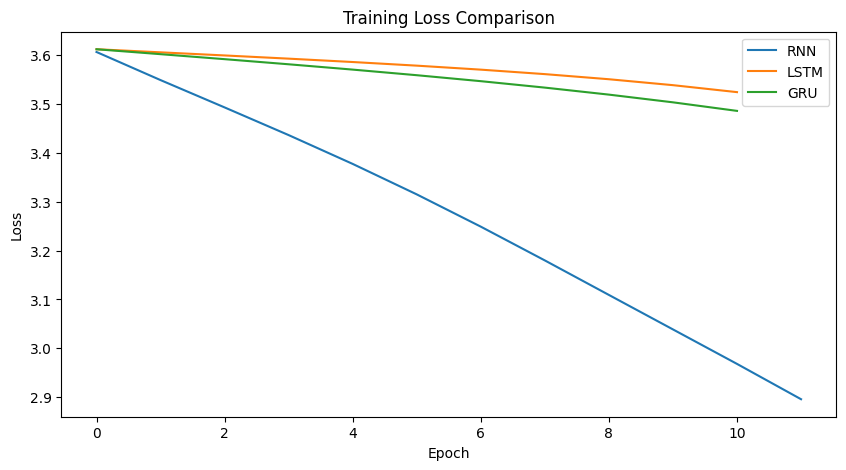

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history["loss"],label="RNN")
plt.plot(lstm_history.history["loss"],label="LSTM")
plt.plot(gru_history.history["loss"],label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# Accuracy Comparision

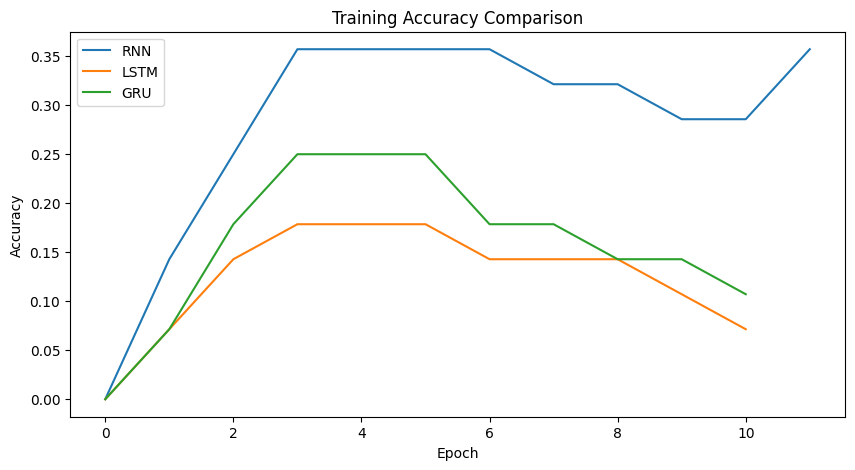

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history["accuracy"],label="RNN")
plt.plot(lstm_history.history["accuracy"],label="LSTM")
plt.plot(gru_history.history["accuracy"],label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# Validation Loss Comparision

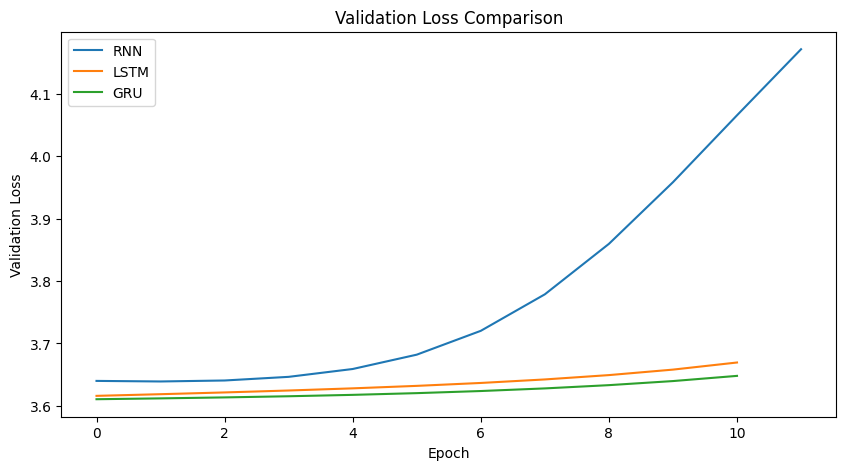

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history["val_loss"],label="RNN")
plt.plot(lstm_history.history["val_loss"],label="LSTM")
plt.plot(gru_history.history["val_loss"],label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

# Text Generation Function

In [ ]:
def generate_text(model,seed_text,next_words=10):
    for i in range(next_words):
        token_list=tokenizer.texts_to_sequences([seed_text])[0]
        token_list=pad_sequences([token_list],maxlen=max_len-1,padding="pre")

        predicted=np.argmax(model.predict(token_list,verbose=0),axis=-1)[0]

        output_word=""
        for word,index in tokenizer.word_index.items():
            if index==predicted:
                output_word=word
                break

        seed_text+=" "+output_word

    return seed_text

# Generate text

In [ ]:
print("Vanilla RNN")
print(generate_text(rnn_model,"deep learning"))

print()

print("LSTM")
print(generate_text(lstm_model,"deep learning"))

print()

print("GRU")
print(generate_text(gru_model,"deep learning"))

Vanilla RNN
deep learning sentences sentences sentences sequential sequential are meaningful word recurrent long

LSTM
deep learning intelligence intelligence transforming models are are useful are next next

GRU
deep learning is is is is is is is is is is


# Performnce comparision table

In [ ]:
import pandas as pd

comparison=pd.DataFrame({
    "Model":["Vanilla RNN","LSTM","GRU"],
    "Test Accuracy":[rnn_acc,lstm_acc,gru_acc],
    "Test Loss":[rnn_loss,lstm_loss,gru_loss]
})

comparison

,Model,Test Accuracy,Test Loss
0,Vanilla RNN,0.0,3.639019
1,LSTM,0.0,3.615960
2,GRU,0.0,3.610571


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**